# Climate Signal Detection with LSTM
### Detecting Anthropogenic Warming in the HadCET Record (1659–2025)



## Load Saved Data
Loads the preprocessed training and test sets saved from the data preparation notebook




In [2]:
import pandas as pd
import numpy as np

train = pd.read_csv('hadcet_train.csv')
test = pd.read_csv('hadcet_test.csv')

print(f"Train: {len(train)} rows")
print(f"Test: {len(test)} rows")

Train: 1560 rows
Test: 900 rows


## Import Libraries and Scale Features
Imports PyTorch and scikit-learn, defines the 5 input features and target, then standardises everything to zero mean and unit variance.

Features used: NAO index, sunspot number, aerosol optical depth, month sine, month cosine.

Scalers are fitted on training data only, then applied to test data. Fitting on test data would constitute data leakage and invalidate all results.

In [3]:
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Features the model uses to predict temperature
feature_cols = ['nao', 'sunspot', 'aod_global', 'month_sin', 'month_cos']
target_col = 'temp_c'

# Scale features and target separately
scaler_X = StandardScaler()
scaler_y = StandardScaler()

train_X = scaler_X.fit_transform(train[feature_cols])
train_y = scaler_y.fit_transform(train[[target_col]])

test_X = scaler_X.transform(test[feature_cols])
test_y = scaler_y.transform(test[[target_col]])

print(f"Train X shape: {train_X.shape}")
print(f"Train y shape: {train_y.shape}")

Train X shape: (1560, 5)
Train y shape: (1560, 1)


## Create Sequences
Transforms the flat time series into overlapping 24 month windows. For each target month, the model receives the previous 24 months of all 5 features as context.

24 months was chosen to capture two full annual cycles, allowing the model to learn both the seasonal cycle and inter-annual NAO variability.
Output: (1536, 24, 5) 1,536 training sequences × 24 months × 5 features

In [4]:
def create_sequences(X, y, window=24):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

WINDOW = 24

X_train_seq, y_train_seq = create_sequences(train_X, train_y, WINDOW)
X_test_seq, y_test_seq = create_sequences(test_X, test_y, WINDOW)

print(f"Train sequences: {X_train_seq.shape}")
print(f"Test sequences:  {X_test_seq.shape}")

Train sequences: (1536, 24, 5)
Test sequences:  (876, 24, 5)


## Convert to Tensors and Define the LSTM
Converts numpy arrays to PyTorch tensors, wraps training data in a DataLoader with batch size 32, and defines the LSTM architecture.

Architecture choices:
- `hidden_dim=64` — large enough to capture climate interactions, small enough to avoid overfitting
- `num_layers=2` — two stacked layers allow the model to learn hierarchical patterns, seasonal cycle in layer 1 and inter-annual variability in layer 2
- `dropout=0.2` — randomly zeros 20% of connections during training to prevent memorisation
- `batch_first=True` — input shape is (batch, sequence, features)
- `out[:, -1, :]` — takes on

In [5]:
X_train_t = torch.FloatTensor(X_train_seq)
y_train_t = torch.FloatTensor(y_train_seq)
X_test_t  = torch.FloatTensor(X_test_seq)
y_test_t  = torch.FloatTensor(y_test_seq)

train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

# Define the LSTM model
class ClimateLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = ClimateLSTM(input_dim=5, hidden_dim=64, num_layers=2, dropout=0.2)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

ClimateLSTM(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 51,521


## Train the Model
Runs the training loop for 200 epochs using Adam optimiser and MSE loss.

- `Adam` — adaptive learning rate optimiser, well suited to LSTMs
- `weight_decay=1e-4` — L2 regularisation to penalise large weights
- `ReduceLROnPlateau` — halves the learning rate when test loss stops improving
- `torch.no_grad()` — disables gradient computation during evaluation, saving memory

Observed training behaviour:

| Epoch | Train Loss | Test Loss |
|---|---|---|
| 20 | 0.0921 | 0.1104 |
| 60 | 0.0879 | 0.1059 |
| 100 | 0.0872 | 0.1076 |
| 200 | 0.0867 | 0.1076 |

Train and test losses stayed close throughout no overfitting. Converged around epoch 60 and remained stable to epoch 200.

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=10, factor=0.5
)

EPOCHS = 200
train_losses, test_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for xb, yb in train_dl:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_t)
        test_loss = criterion(test_pred, y_test_t).item()

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    scheduler.step(test_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f}")

print("\nTraining complete.")

Epoch  20 | Train loss: 0.0921 | Test loss: 0.1104
Epoch  40 | Train loss: 0.0890 | Test loss: 0.1063
Epoch  60 | Train loss: 0.0879 | Test loss: 0.1059
Epoch  80 | Train loss: 0.0873 | Test loss: 0.1074
Epoch 100 | Train loss: 0.0872 | Test loss: 0.1076
Epoch 120 | Train loss: 0.0876 | Test loss: 0.1076
Epoch 140 | Train loss: 0.0874 | Test loss: 0.1076
Epoch 160 | Train loss: 0.0870 | Test loss: 0.1076
Epoch 180 | Train loss: 0.0878 | Test loss: 0.1076
Epoch 200 | Train loss: 0.0867 | Test loss: 0.1076

Training complete.


## Results and Climate Signal Detection
Inverse transforms predictions back to Celsius and produces three plots.

**Plot 1 — Training fit (1821–1950):** Model prediction vs observed temperature on pre-industrial data. Confirms the model successfully learned natural variability patterns including seasonal cycles and volcanic cooling events.

**Plot 2 — Modern period (1951–2025):** Model prediction vs observed temperature on data the model never saw during training. The model predicts what temperature should be under natural forcing alone.

**Plot 3 — The climate signal:** Residual (observed minus predicted) with a linear trend. A flat line would mean natural variability explains everything. An upward trend is the anthropogenic signal.

**Key result: 0.190°C of warming per decade** — 1.4°C total over 1951–2025 that natural forcing alone cannot explain. Consistent with IPCC AR6 estimates of global mean warming since pre-industrial times.

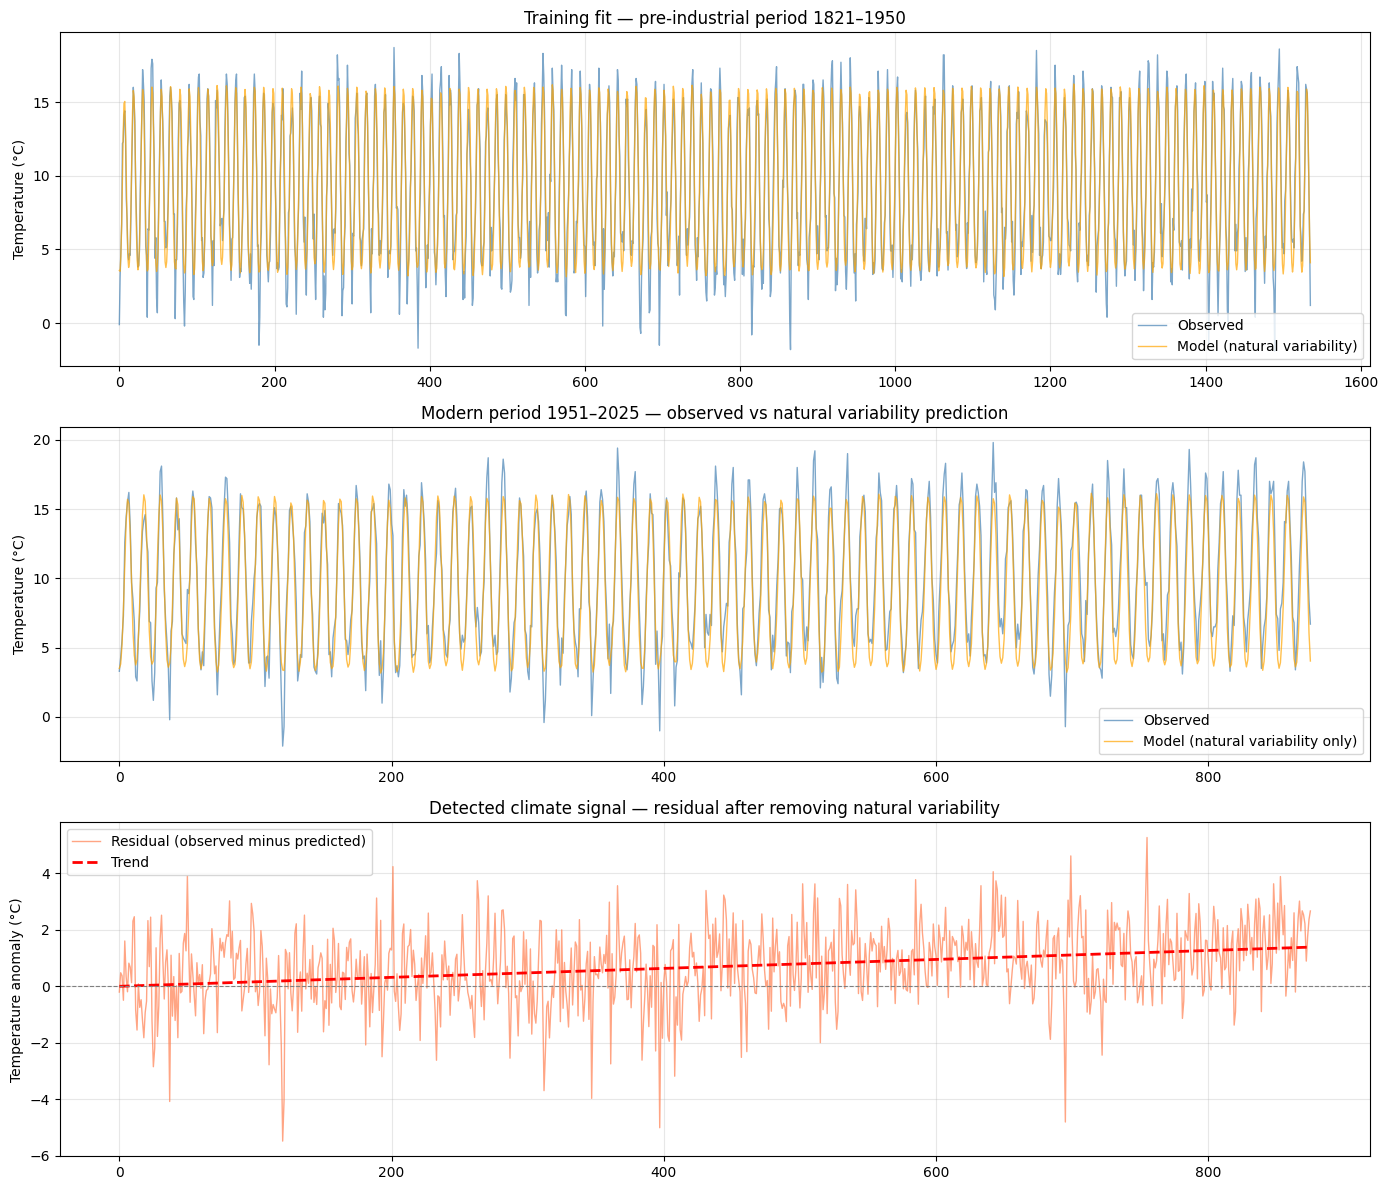

Detected warming trend: 0.190°C per decade


In [9]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    test_pred_scaled = model(X_test_t).numpy()
    train_pred_scaled = model(X_train_t).numpy()

# Inverse transform back to celsius
test_pred = scaler_y.inverse_transform(test_pred_scaled)
test_actual = scaler_y.inverse_transform(y_test_seq)
train_pred = scaler_y.inverse_transform(train_pred_scaled)
train_actual = scaler_y.inverse_transform(y_train_seq)

# Date arrays for plotting
train_dates = train['date'].values[WINDOW:]
test_dates = test['date'].values[WINDOW:]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1 — training fit
axes[0].plot(range(len(train_actual)), train_actual, lw=1, 
             color='steelblue', label='Observed', alpha=0.7)
axes[0].plot(range(len(train_pred)), train_pred, lw=1, 
             color='orange', label='Model (natural variability)', alpha=0.7)
axes[0].set_title('Training fit — pre-industrial period 1821–1950')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2 — model vs observed modern period
axes[1].plot(range(len(test_actual)), test_actual, lw=1, 
             color='steelblue', label='Observed', alpha=0.7)
axes[1].plot(range(len(test_pred)), test_pred, lw=1, 
             color='orange', label='Model (natural variability only)', alpha=0.7)
axes[1].set_title('Modern period 1951–2025 — observed vs natural variability prediction')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3 — the residual (the climate signal)
residual = test_actual.ravel() - test_pred.ravel()
axes[2].plot(range(len(residual)), residual, lw=1, 
             color='coral', alpha=0.7, label='Residual (observed minus predicted)')
z = np.polyfit(range(len(residual)), residual, 1)
p = np.poly1d(z)
axes[2].plot(range(len(residual)), p(range(len(residual))), 
             lw=2, color='red', linestyle='--', label='Trend')
axes[2].axhline(0, color='gray', lw=0.8, linestyle='--')
axes[2].set_title('Detected climate signal — residual after removing natural variability')
axes[2].set_ylabel('Temperature anomaly (°C)')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('climate_signal_detection.png', dpi=150)
plt.show()

# Print the trend
trend_per_decade = z[0] * 12 * 10
print(f"Detected warming trend: {trend_per_decade:.3f}°C per decade")

## Save the Model
Saves the trained model and all associated objects to a single `.pt` file.

Saved objects:
- `model_state` — the trained LSTM weights
- `scaler_X` and `scaler_y` — scalers needed to transform any new data before inference
- `feature_cols` and `window` — ensures the model is always used with the correct inputs
- `train_loss_final` and `test_loss_final` — records final performance metrics alongside the model
- `warming_trend_per_decade` — embeds the key scientific result directly in the saved file

In [10]:
torch.save({
    'model_state': model.state_dict(),
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'feature_cols': feature_cols,
    'window': WINDOW,
    'train_loss_final': train_losses[-1],
    'test_loss_final': test_losses[-1],
    'warming_trend_per_decade': trend_per_decade
}, 'climate_lstm.pt')

print("Model saved to climate_lstm.pt")

Model saved to climate_lstm.pt
